In [58]:
import pandas as pd
from pathlib import Path
import seaborn as sns
import matplotlib.pyplot as plt




# All trade combiantions baseline 
SUMMARY_DIR = Path("./results")
files = sorted(SUMMARY_DIR.glob("summary_*.csv"))
df = pd.concat(
    (pd.read_csv(f, parse_dates=["day"]) for f in files),
    ignore_index=True
)
df["day"] = pd.to_datetime(df["day"] , utc=True).dt.normalize()




# Open positions only V3
SUMMARY_DIR = Path("./results_open_positions_V3")
files = sorted(SUMMARY_DIR.glob("summary_*.csv"))
df_open_pos_V3 = pd.concat(
    (pd.read_csv(f, parse_dates=["day"]) for f in files),
    ignore_index=True
)
df_open_pos_V3["day"] = pd.to_datetime(df_open_pos_V3["day"] , utc=True).dt.normalize()



ri_base = (
    df[df["combo_id"] == 0][["day", "profit"]]
    .rename(columns={"profit": "RI_base"})
)



df = df.merge(ri_base, on="day", how="left")
df["uplift_abs"] = df["profit"] - df["RI_base"]
df["uplift_pct"] = df["uplift_abs"] / df["RI_base"]


df_open_pos_V3 = df_open_pos_V3.merge(ri_base, on="day", how="left")
df_open_pos_V3["uplift_abs"] = df_open_pos_V3["profit"] - df_open_pos_V3["RI_base"]
df_open_pos_V3["uplift_pct"] = df_open_pos_V3["uplift_abs"] / df_open_pos_V3["RI_base"]

In [59]:
start_date = pd.Timestamp("2019-01-01", tz="UTC")
end_date = pd.Timestamp("2025-12-31", tz="UTC")

df = df.loc[(df["day"] >= start_date) & (df["day"] <= end_date)].copy()
df_open_pos_V3 = df_open_pos_V3.loc[(df_open_pos_V3["day"] >= start_date) & (df_open_pos_V3["day"] <= end_date)].copy()


In [60]:
df.loc[(df["kind"] != "no_da") & (df["sell_hour"].isna()), "sell_hour"] = 0
df_open_pos_V3.loc[(df_open_pos_V3["kind"] != "no_da") & (df_open_pos_V3["sell_hour"].isna()), "sell_hour"] = 0

df.loc[(df["sell_hour"].isna()), "sell_hour"] = 0
df_open_pos_V3.loc[(df_open_pos_V3["sell_hour"].isna()), "sell_hour"] = 0

df.loc[(df["buy_hour"].isna()), "buy_hour"] = 0
df_open_pos_V3.loc[(df_open_pos_V3["buy_hour"].isna()), "buy_hour"] = 0

df_no_da = df[df["kind"].isin(["no_da", "buy_only"])]
df_open_no_da_v3 = df_open_pos_V3[df_open_pos_V3["kind"].isin(["no_da", "buy_only"])]

# Merge: _left = Baseline (./results), _right = Open Positions V3 (./results_open_positions_V3).
# Schlüssel: (day, combo_id). Outer = alle Keys aus beiden; Zeilen nur in einer Quelle haben
# dann NaN in der jeweils anderen Profit-Spalte (und kind/Profit_df nur von links).
KEYS = ["day", "combo_id"]

_left = df_no_da[["day", "combo_id", "kind", "profit"]].rename(columns={"profit": "Profit_df"})
_right = df_open_no_da_v3[["day", "combo_id", "profit"]].rename(
    columns={"profit": "Profit_df_open_pos_V3"}
)

comparison = _left.merge(_right, on=KEYS, how="outer", indicator="_merge")
comparison = comparison.sort_values(KEYS).reset_index(drop=True)
comparison.insert(0, "row_id", range(1, len(comparison) + 1))

# Nur Keys, die in BEIDEN Datensätzen vorkommen (keine halbleeren Zeilen durch outer)
comparison_both = comparison[comparison["_merge"] == "both"].copy()

# Volle Zeilen, die nur in einer Quelle existieren (zum Prüfen / Export)
only_in_baseline = _left.merge(_right[KEYS], on=KEYS, how="left", indicator=True)
only_in_baseline = only_in_baseline[only_in_baseline["_merge"] == "left_only"].drop(
    columns=["_merge"]
)

only_in_v3 = _right.merge(_left[KEYS], on=KEYS, how="left", indicator=True)
only_in_v3 = only_in_v3[only_in_v3["_merge"] == "left_only"].drop(columns=["_merge"])

In [61]:
def contiguous_calendar_day_ranges(days) -> pd.DataFrame:
    """Sortierte Kalendertage zu zusammenhängenden Bereichen (je 1 Tag Differenz = gleiche Range)."""
    s = pd.DatetimeIndex(pd.unique(pd.to_datetime(days, utc=True))).sort_values().normalize()
    if len(s) == 0:
        return pd.DataFrame(columns=["range_start", "range_end", "n_days"])
    day_series = s.to_series().reset_index(drop=True)
    new_group = day_series.diff().dt.days.ne(1)
    new_group.iloc[0] = True
    gid = new_group.cumsum()
    return (
        day_series.groupby(gid, sort=False)
        .agg(range_start="min", range_end="max", n_days="count")
        .reset_index(drop=True)
    )


# Kalenderabdeckung auf df_no_da / df_open_no_da_v3 (nicht nur die "orphan"-Key-Zeilen)
set_days_baseline = set(pd.DatetimeIndex(_left["day"].unique()).normalize())
set_days_v3 = set(pd.DatetimeIndex(_right["day"].unique()).normalize())

days_missing_in_v3 = sorted(set_days_baseline - set_days_v3)
days_missing_in_baseline = sorted(set_days_v3 - set_days_baseline)

calendar_ranges_missing_in_v3 = contiguous_calendar_day_ranges(days_missing_in_v3)
calendar_ranges_missing_in_baseline = contiguous_calendar_day_ranges(days_missing_in_baseline)

print("Eindeutige Kalendertage in Baseline (./results, no_da|buy_only):", len(set_days_baseline))
print("Eindeutige Kalendertage in V3 (./results_open_positions_V3):", len(set_days_v3))
print(
    "(Hinweis: Fehlen nur einzelne combo_id an einem Tag, der in beiden Quellen vorkommt,\n"
    " taucht das nicht hier auf — dann siehe only_in_baseline / only_in_v3.)\n"
)
print(
    "Kalendertage in Baseline, für die es in V3 keinen einzigen Eintrag (kein combo_id) gibt:",
    len(days_missing_in_v3),
)
print(calendar_ranges_missing_in_v3.to_string(index=False))
print()
print(
    "Kalendertage in V3, für die es in der Baseline keinen einzigen Eintrag gibt:",
    len(days_missing_in_baseline),
)
print(calendar_ranges_missing_in_baseline.to_string(index=False))

Eindeutige Kalendertage in Baseline (./results, no_da|buy_only): 2211
Eindeutige Kalendertage in V3 (./results_open_positions_V3): 2494
(Hinweis: Fehlen nur einzelne combo_id an einem Tag, der in beiden Quellen vorkommt,
 taucht das nicht hier auf — dann siehe only_in_baseline / only_in_v3.)

Kalendertage in Baseline, für die es in V3 keinen einzigen Eintrag (kein combo_id) gibt: 0
Empty DataFrame
Columns: [range_start, range_end, n_days]
Index: []

Kalendertage in V3, für die es in der Baseline keinen einzigen Eintrag gibt: 283
              range_start                 range_end  n_days
2023-12-31 00:00:00+00:00 2024-02-25 00:00:00+00:00      57
2024-02-27 00:00:00+00:00 2024-07-07 00:00:00+00:00     132
2024-12-30 00:00:00+00:00 2024-12-30 00:00:00+00:00       1
2025-07-30 00:00:00+00:00 2025-10-30 00:00:00+00:00      93


In [62]:
print("Merge-Schlüssel:", KEYS)
print("Quelle links (Profit_df): df_no_da  ←  ./results  (kind no_da | buy_only)")
print("Quelle rechts (Profit_df_open_pos_V3): df_open_no_da_v3  ←  ./results_open_positions_V3")
print()
print(comparison["_merge"].value_counts())
print()
print("Zeilen nur in Baseline (fehlen in V3):", len(only_in_baseline))
print("Zeilen nur in V3 (fehlen in Baseline):", len(only_in_v3))
print("Zeilen in beiden:", len(comparison_both))

comparison.describe()

Merge-Schlüssel: ['day', 'combo_id']
Quelle links (Profit_df): df_no_da  ←  ./results  (kind no_da | buy_only)
Quelle rechts (Profit_df_open_pos_V3): df_open_no_da_v3  ←  ./results_open_positions_V3

_merge
both          53064
right_only     6792
left_only         0
Name: count, dtype: int64

Zeilen nur in Baseline (fehlen in V3): 0
Zeilen nur in V3 (fehlen in Baseline): 6792
Zeilen in beiden: 53064


,row_id,combo_id,Profit_df,Profit_df_open_pos_V3
count,59856.000000,59856.000000,53064.000000,59856.000000
mean,29928.500000,11.500000,180.161779,180.250924
std,17279.083193,6.922244,159.115360,157.458487
min,1.000000,0.000000,2.704300,-164.210000
25%,14964.750000,5.750000,76.356993,79.667532
50%,29928.500000,11.500000,138.305040,141.337980
75%,44892.250000,17.250000,235.087836,231.845115
max,59856.000000,23.000000,2605.794157,2504.891490


In [63]:
comparison = comparison.dropna()

In [64]:
comparison.describe()

,row_id,combo_id,Profit_df,Profit_df_open_pos_V3
count,53064.000000,53064.000000,53064.000000,53064.000000
mean,27326.692673,11.500000,180.161779,179.455922
std,16505.500919,6.922252,159.115360,158.567380
min,1.000000,0.000000,2.704300,-164.210000
25%,13266.750000,5.750000,76.356993,75.505581
50%,26532.500000,11.500000,138.305040,137.334624
75%,39798.250000,17.250000,235.087836,234.642703
max,57624.000000,23.000000,2605.794157,2504.891490


#### Visuals

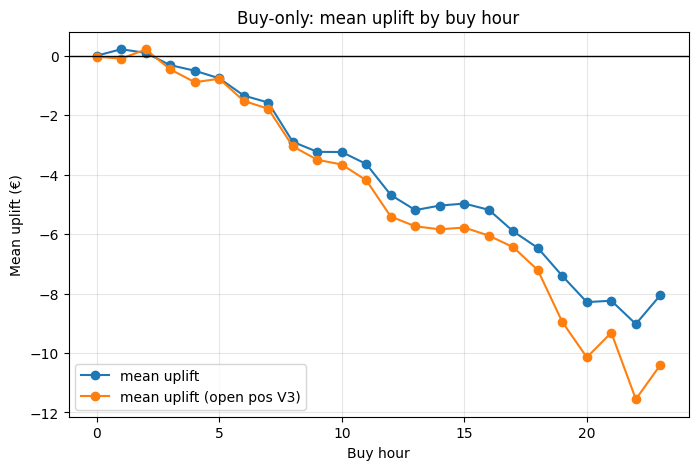

In [65]:
def compute_buy_only_stats(df):
    buy_only = df[(df["kind"] == "buy_only")  | (df["kind"] == "no_da")]  #& (df["combo_id"] != 0)]

    stats = (
        buy_only
        .groupby("buy_hour")["uplift_abs"]
        .agg(
            mean="mean",
            median="median",
            success_rate=lambda x: (x > 0).mean(),
            count="count",
        )
        .reset_index()
    )
    return stats

stats_df = compute_buy_only_stats(df)
stats_df_open_pos_V3 = compute_buy_only_stats(df_open_pos_V3)




plt.figure(figsize=(8, 5))
plt.plot(
    stats_df["buy_hour"],
    stats_df["mean"],
    label="mean uplift",
    marker="o"
)


plt.plot(
    stats_df_open_pos_V3["buy_hour"],
    stats_df_open_pos_V3["mean"],
    label="mean uplift (open pos V3)",
    marker="o"
)

plt.axhline(0, color="black", linewidth=1)
plt.title("Buy-only: mean uplift by buy hour")
plt.xlabel("Buy hour")
plt.ylabel("Mean uplift (€)")
plt.legend()
plt.grid(True, alpha=0.3)

plt.show()